In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"C:\Users\borse\OneDrive\Desktop\Customer Retention & Segmentation Analysis (Python + Power BI)\customer_shopping_behavior.csv")

In [3]:
df.head()

,Transaction ID,Customer ID,Purchase Date,Age,Gender,Location,Online/Offline,Online Store,Category,Item Purchased,...,Festival/Sale,Shipping Charge (₹),Delivery Speed,Delivery Time (Days),Subscription Status,Payment Method,Review Rating,Return Status,Previous Purchases,Frequency of Purchases
0,TXN507808,CUST102534,2023-01-01,51,Male,Chennai,Online,Flipkart,Clothing,Kurta,...,NaN,0,Same Day,1,Yes,Cash on Delivery,4,Not Returned,0,Fortnightly
1,TXN503830,CUST101256,2023-01-01,27,Female,Mumbai,Offline,NaN,Clothing,Shirt,...,NaN,0,NaN,0,No,UPI,5,Not Returned,0,Fortnightly
2,TXN501496,CUST100490,2023-01-01,57,Male,Hyderabad,Online,Flipkart,Clothing,Jacket,...,NaN,0,Standard,7,Yes,UPI,3,Not Returned,0,Rarely
3,TXN501538,CUST100500,2023-01-01,22,Female,Pune,Online,Myntra,Clothing,Kurta,...,NaN,0,Standard,6,Yes,Net Banking,4,Not Returned,0,Fortnightly
4,TXN504265,CUST101399,2023-01-01,30,Male,Visakhapatnam,Online,Myntra,Accessories,Cap,...,NaN,99,Express,2,No,Debit Card,4,Not Returned,0,Weekly


In [4]:
df.describe

<bound method NDFrame.describe of      Transaction ID Customer ID Purchase Date  Age  Gender       Location  \
0         TXN507808  CUST102534    2023-01-01   51    Male        Chennai   
1         TXN503830  CUST101256    2023-01-01   27  Female         Mumbai   
2         TXN501496  CUST100490    2023-01-01   57    Male      Hyderabad   
3         TXN501538  CUST100500    2023-01-01   22  Female           Pune   
4         TXN504265  CUST101399    2023-01-01   30    Male  Visakhapatnam   
...             ...         ...           ...  ...     ...            ...   
9995      TXN509420  CUST102996    2024-12-31   30    Male      Bangalore   
9996      TXN500945  CUST100273    2024-12-31   58  Female        Kolkata   
9997      TXN501737  CUST100566    2024-12-31   27  Female        Chennai   
9998      TXN506133  CUST102017    2024-12-31   48    Male      Bangalore   
9999      TXN501759  CUST100573    2024-12-31   20    Male           Pune   

     Online/Offline Online Store     Cate

In [5]:
df.shape

(10000, 26)

In [6]:
print("\nMissing values before cleaning:")
print(df.isna().sum()[df.isna().sum() > 0])


Missing values before cleaning:
Online Store      2249
Size              1035
Festival/Sale     6788
Delivery Speed    2249
dtype: int64


In [7]:
rows_before = len(df)

In [8]:
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"], errors="coerce")

In [9]:
print("\nBad dates:", df["Purchase Date"].isna().sum())


Bad dates: 0


In [10]:
df = df.drop_duplicates()
df = df.drop_duplicates(subset="Transaction ID")

In [11]:
for c in df.columns:
    if pd.api.types.is_string_dtype(df[c]) or df[c].dtype == object:
        df[c] = df[c].str.strip()

In [12]:
df["Online Store"] = df["Online Store"].fillna("In-Store Purchase") 

In [13]:
df["Delivery Speed"] = df["Delivery Speed"].fillna("N/A (Offline)")  

In [14]:
df["Festival/Sale"] = df["Festival/Sale"].fillna("No Sale") 

In [15]:
df["Size"] = df["Size"].fillna("No Size")  

In [16]:
df["Order Month"] = df["Purchase Date"].dt.to_period("M")
df["Is Returned"] = (df["Return Status"] == "Returned").astype(int)

In [17]:
print(f"\nRows before: {rows_before}, after: {len(df)}")
print("Missing values after cleaning:", int(df.isna().sum().sum()))


Rows before: 10000, after: 10000
Missing values after cleaning: 0


In [18]:
df["Cohort Month"] = df.groupby("Customer ID")["Order Month"].transform("min")

In [19]:
df["Months Since First"] = (
    (df["Order Month"].dt.year - df["Cohort Month"].dt.year) * 12
    + (df["Order Month"].dt.month - df["Cohort Month"].dt.month)
)

In [20]:
cohort_counts = (
    df.groupby(["Cohort Month", "Months Since First"])["Customer ID"]
    .nunique()
    .unstack(fill_value=0)
)

In [21]:
cohort_size = cohort_counts[0]  

In [22]:
retention = cohort_counts.divide(cohort_size, axis=0).round(3)

In [23]:
print("\nRetention table (first 6 cohorts, first 6 months):")
print(retention.iloc[:6, :6])


Retention table (first 6 cohorts, first 6 months):
Months Since First    0      1      2      3      4      5
Cohort Month                                              
2023-01             1.0  0.178  0.239  0.206  0.206  0.185
2023-02             1.0  0.212  0.171  0.225  0.180  0.126
2023-03             1.0  0.125  0.219  0.149  0.128  0.198
2023-04             1.0  0.167  0.107  0.107  0.067  0.113
2023-05             1.0  0.127  0.103  0.157  0.113  0.137
2023-06             1.0  0.096  0.088  0.064  0.152  0.160


In [24]:
snapshot = df["Purchase Date"].max() + pd.Timedelta(days=1)

In [25]:
rfm = df.groupby("Customer ID").agg(
    Recency=("Purchase Date", lambda x: (snapshot - x.max()).days),
    Frequency=("Transaction ID", "count"),
    Monetary=("Purchase Amount (₹)", "sum"),
)

In [26]:
rfm["R"] = pd.qcut(rfm["Recency"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["Monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

In [27]:
def segment(row):
    if row["R"] >= 4 and row["F"] >= 4:
        return "Champions"
    if row["F"] >= 4:
        return "Loyal"
    if row["R"] >= 4 and row["F"] <= 2:
        return "New / Recent"
    if row["R"] <= 2 and row["F"] >= 3:
        return "At Risk"
    if row["R"] <= 2:
        return "Lost"
    return "Needs Attention"

In [28]:
rfm["Segment"] = rfm.apply(segment, axis=1)

In [29]:
seg_summary = (
    rfm.groupby("Segment")
    .agg(Customers=("Monetary", "size"),
         Avg_Spend=("Monetary", "mean"),
         Total_Spend=("Monetary", "sum"))
    .round(0)
    .sort_values("Total_Spend", ascending=False)
)
seg_summary["Share of Revenue %"] = (
    seg_summary["Total_Spend"] / seg_summary["Total_Spend"].sum() * 100
).round(1)

In [30]:
 
print("\nRFM segment summary:")
print(seg_summary)


RFM segment summary:
                 Customers  Avg_Spend  Total_Spend  Share of Revenue %
Segment                                                               
Champions              638    15384.0      9815304                51.9
Loyal                  394    10374.0      4087181                21.6
Needs Attention        473     4260.0      2014833                10.7
Lost                   665     2282.0      1517673                 8.0
At Risk                200     4752.0       950417                 5.0
New / Recent           211     2433.0       513412                 2.7


In [31]:
first_order = (
    df.sort_values("Purchase Date")
    .groupby("Customer ID")
    .first()[["Online Store"]]
    .rename(columns={"Online Store": "First Platform"})
)

In [32]:
cust = rfm.join(first_order)
cust["Is Repeat"] = (cust["Frequency"] >= 2).astype(int)

In [33]:
platform = (
    cust.groupby("First Platform")
    .agg(Customers=("Monetary", "size"),
         Repeat_Rate=("Is Repeat", "mean"),
         Avg_Orders=("Frequency", "mean"),
         Avg_Customer_Value=("Monetary", "mean"))
    .round(2)
    .sort_values("Avg_Customer_Value", ascending=False)
)
platform["Repeat_Rate"] = (platform["Repeat_Rate"] * 100).round(1)

In [34]:
print("\nPlatform comparison (by customer's first order):")
print(platform)


Platform comparison (by customer's first order):
                   Customers  Repeat_Rate  Avg_Orders  Avg_Customer_Value
First Platform                                                           
Ajio                     302         74.0        3.91             8096.34
Meesho                   170         72.0        4.46             8062.22
Myntra                   528         72.0        3.85             7386.28
Flipkart                 407         73.0        3.96             7180.27
Shein                    131         69.0        3.89             7136.24
In-Store Purchase        589         72.0        3.72             7039.54
Amazon                   454         72.0        3.77             7003.70


In [35]:
import numpy as np

last = df["Order Month"].max()
for c in retention.index:
    max_m = (last.year - c.year) * 12 + (last.month - c.month)
    retention.loc[c, retention.columns > max_m] = np.nan

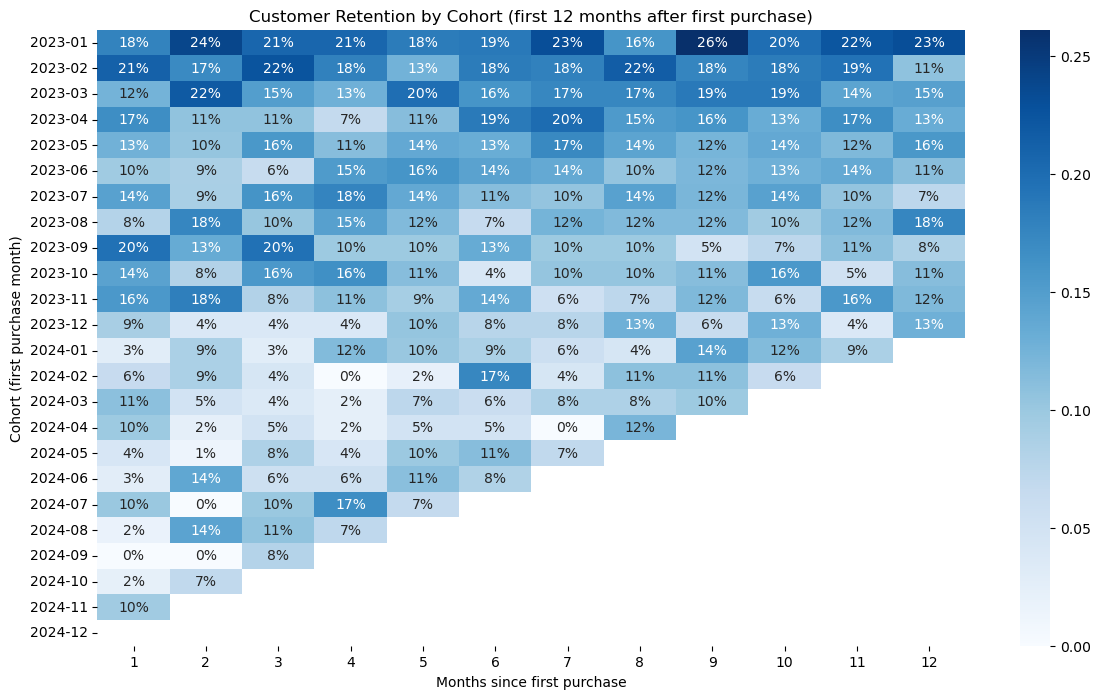

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.heatmap(retention.iloc[:, 1:13], annot=True, fmt=".0%", cmap="Blues")
plt.title("Customer Retention by Cohort (first 12 months after first purchase)")
plt.xlabel("Months since first purchase")
plt.ylabel("Cohort (first purchase month)")
plt.savefig("retention_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
retention_long = retention.reset_index().melt(
    id_vars="Cohort Month", var_name="Months Since First", value_name="Retention")
retention_long["Cohort Month"] = retention_long["Cohort Month"].astype(str)

df.to_csv("shopping_cleaned.csv", index=False)
retention_long.to_csv("cohort_retention.csv", index=False)
rfm.reset_index().to_csv("rfm_segments.csv", index=False)
seg_summary.reset_index().to_csv("segment_summary.csv", index=False)
platform.reset_index().to_csv("platform_comparison.csv", index=False)

print(retention_long["Retention"].isna().sum(), "blank cells exported")

276 blank cells exported
